Derin özellikler odaklanıyoruz.

Found 3239 images belonging to 5 classes.
Found 810 images belonging to 5 classes.
1/1 [==============================] - 4s 4s/step
Ara katmandan çıkarılan özelliklerin boyutları: (16, 10, 10, 512)


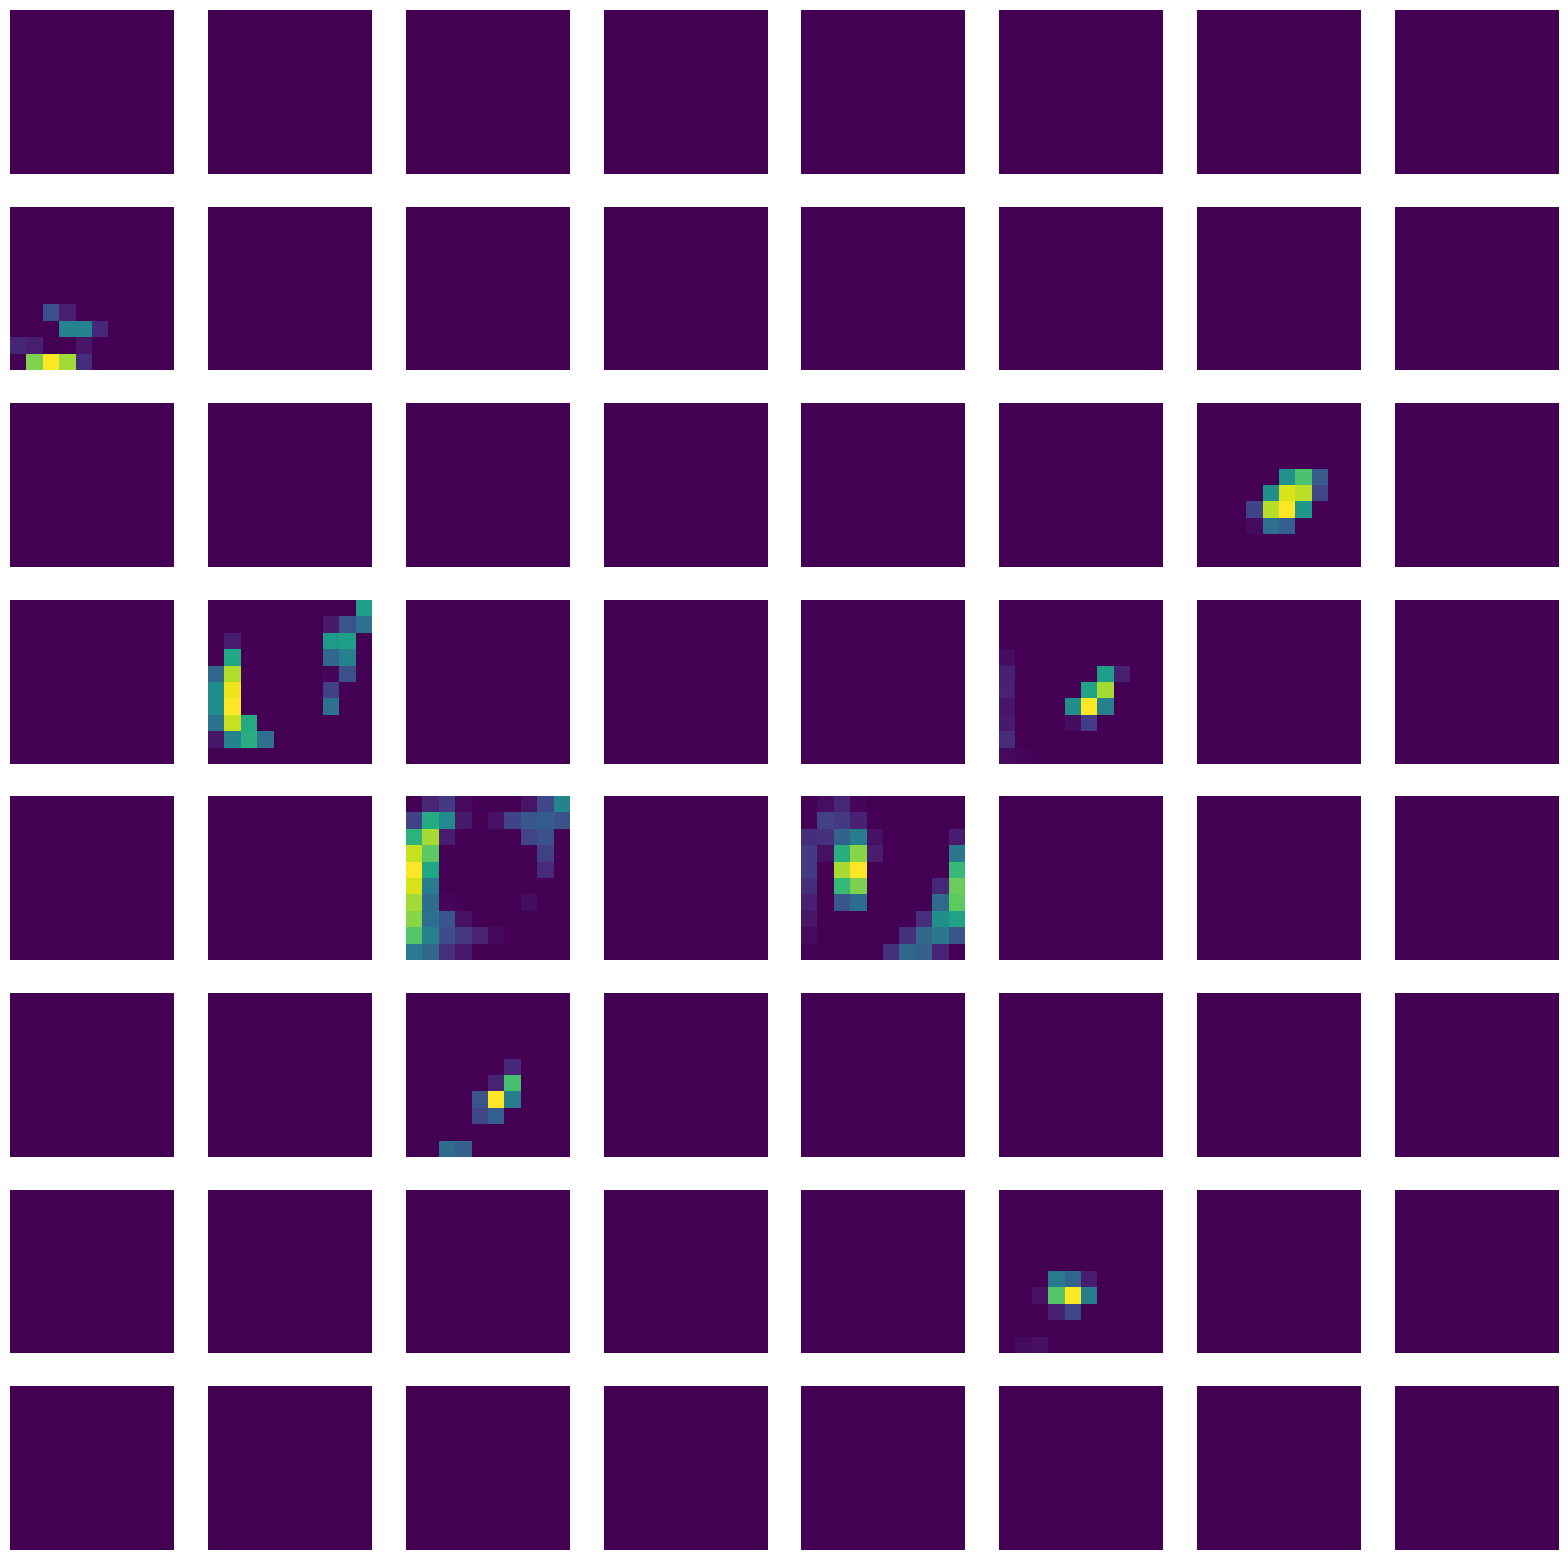

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image_dataset_from_directory
import os
import matplotlib.pyplot as plt

# Veri setlerini yüklemek için yol belirtilir
ds_name = "images"
ds_training_path = os.path.join(ds_name, "train")
ds_testing_path = os.path.join(ds_name, "test")

batch_size = 16
target_size = (224, 224)

data_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_gen = data_gen.flow_from_directory(
    ds_training_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True
)

valid_gen = data_gen.flow_from_directory(
    ds_testing_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# Eğitilmiş modeli yükleme
model = tf.keras.models.load_model("model1.h5")

# Derin özellikleri çıkarmak için ara katmanı belirleme
layer_name = 'conv2d_29'

# Ara katmandan özellikleri çıkartacak yeni model oluşturma
intermediate_layer_model = Model(inputs=model.input, outputs=model.get_layer(layer_name).output)

# Özellikleri çıkartmak için veri kümesinden bir örnek seçme
for x, y in valid_gen:
    break  # İlk batch'ten verileri al

# Özellikleri çıkartma
intermediate_output = intermediate_layer_model.predict(x)

# Çıkarılan özelliklerin boyutlarını yazdırma
print("Ara katmandan çıkarılan özelliklerin boyutları:", intermediate_output.shape)

# İlk resmin tüm kanallarını görselleştirme
num_channels = intermediate_output.shape[-1]
fig, axes = plt.subplots(8, 8, figsize=(20, 20))  # 8x8 grid şeklinde görselleştir
for i in range(64):  # İlk 64 kanalı görselleştirme
    ax = axes[i // 8, i % 8]
    ax.imshow(intermediate_output[0, :, :, i], cmap='viridis')
    ax.axis('off')
plt.show()


Found 3239 images belonging to 5 classes.
Found 810 images belonging to 5 classes.
1/1 [==============================] - 1s 703ms/step
Ara katmandan çıkarılan özelliklerin boyutları: (16, 10, 10, 512)


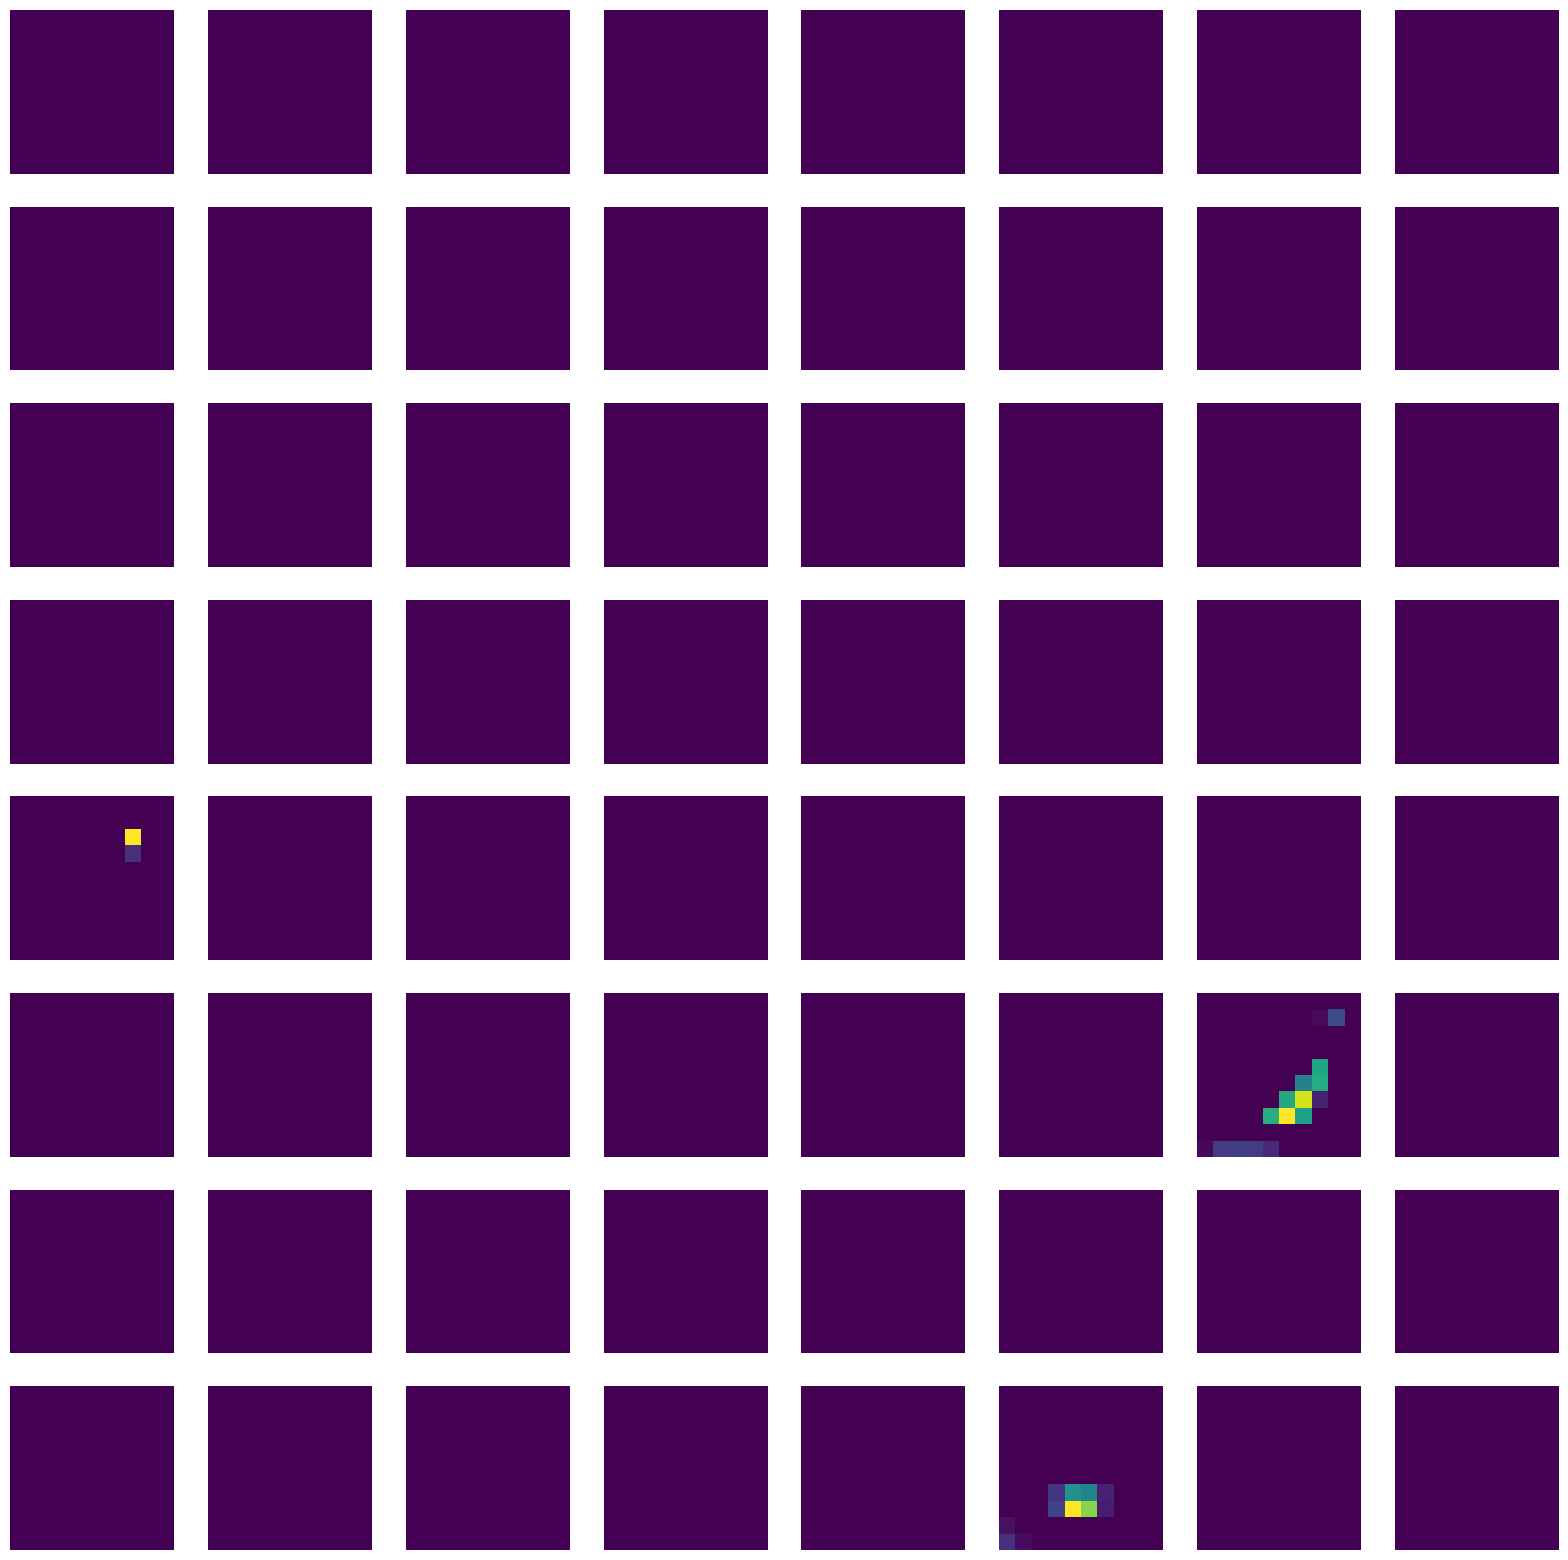

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image_dataset_from_directory
import os
import matplotlib.pyplot as plt

# Veri setlerini yüklemek için yol belirtilir
ds_name = "images"
ds_training_path = os.path.join(ds_name, "train")
ds_testing_path = os.path.join(ds_name, "test")

batch_size = 16
target_size = (224, 224)

data_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_gen = data_gen.flow_from_directory(
    ds_training_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True
)

valid_gen = data_gen.flow_from_directory(
    ds_testing_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# Eğitilmiş modeli yükleme
model = tf.keras.models.load_model("model2.h5")

# Derin özellikleri çıkarmak için ara katmanı belirleme
layer_name = 'conv2d_14'

# Ara katmandan özellikleri çıkartacak yeni model oluşturma
intermediate_layer_model = Model(inputs=model.input, outputs=model.get_layer(layer_name).output)

# Özellikleri çıkartmak için veri kümesinden bir örnek seçme
for x, y in valid_gen:
    break  # İlk batch'ten verileri al

# Özellikleri çıkartma
intermediate_output = intermediate_layer_model.predict(x)

# Çıkarılan özelliklerin boyutlarını yazdırma
print("Ara katmandan çıkarılan özelliklerin boyutları:", intermediate_output.shape)

# İlk resmin tüm kanallarını görselleştirme
num_channels = intermediate_output.shape[-1]
fig, axes = plt.subplots(8, 8, figsize=(20, 20))  # 8x8 grid şeklinde görselleştir
for i in range(64):  # İlk 64 kanalı görselleştirme
    ax = axes[i // 8, i % 8]
    ax.imshow(intermediate_output[0, :, :, i], cmap='viridis')
    ax.axis('off')
plt.show()


In [ ]:
import tensorflow as tf
import visualkeras
from PIL import ImageFont

# Font ayarları (Windows için Arial, diğer sistemlerde uygun bir font seçebilirsiniz)
try:
    font = ImageFont.truetype("arial.ttf", 32)
except IOError:
    font = ImageFont.load_default()

# Modeli görselleştirme
visualkeras.layered_view(intermediate_layer_model, 
                         draw_volume=True,  # Katman hacimlerini çizdirme
                         legend=False,      # Lejant ekleme
                         font=font,        # Yazı tipi ayarı
                         show_dimension=True, # Boyutları gösterme
                         scale_xy=1, 
                         scale_z=1
                        )


In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image_dataset_from_directory
import os
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix

# Veri setlerini yüklemek için yol belirtilir
ds_name = "images"
ds_training_path = os.path.join(ds_name, "train")
ds_testing_path = os.path.join(ds_name, "test")

batch_size = 16
target_size = (224, 224)

data_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_gen = data_gen.flow_from_directory(
    ds_training_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True
)

valid_gen = data_gen.flow_from_directory(
    ds_testing_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# Eğitilmiş modeli yükleme
model = tf.keras.models.load_model("model4.h5")

# Derin özellikleri çıkarmak için ara katmanı belirleme
layer_name = 'conv2d_14'

intermediate_layer_model = Model(inputs=model.input, outputs=model.get_layer(layer_name).output)

def extract_features(data_gen, intermediate_layer_model):
    features = []
    labels = []
    for x, y in data_gen:
        intermediate_output = intermediate_layer_model.predict(x)
        flattened_output = intermediate_output.reshape(intermediate_output.shape[0], -1)
        features.append(flattened_output)
        labels.append(y)
    return np.concatenate(features), np.concatenate(labels)

# Eğitim ve test veri setleri için özellikleri çıkarma
train_features, train_labels = extract_features(train_gen, intermediate_layer_model)
test_features, test_labels = extract_features(valid_gen, intermediate_layer_model)



Found 3239 images belonging to 5 classes.
Found 810 images belonging to 5 classes.


ValueError: Unknown layer: LocalAttention. Please ensure this object is passed to the `custom_objects` argument. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.

In [ ]:
# SVM modelini eğitme
svm_model = svm.SVC(kernel='linear')
svm_model.fit(train_features, np.argmax(train_labels, axis=1))

# Test veri seti üzerinde tahmin yapma
test_predictions = svm_model.predict(test_features)

# Sınıflandırma raporu ve hata matrisi
print("Classification Report:")
print(classification_report(np.argmax(test_labels, axis=1), test_predictions))

print("Confusion Matrix:")
print(confusion_matrix(np.argmax(test_labels, axis=1), test_predictions))
